In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

In [3]:
df=pd.read_csv('/Users/omartharwat/Desktop/Eplison/Final_project/cleaned_amazon_sales.csv')

In [4]:
df.describe()

,Qty,Amount,year,month,day,Amount_missing
count,124460.000000,124460.000000,124460.0,124460.000000,124460.000000,124460.000000
mean,0.909296,658.388774,2022.0,4.911112,14.942126,0.018311
std,0.307613,259.865959,0.0,0.818889,8.737475,0.134074
min,0.000000,0.000000,2022.0,3.000000,1.000000,0.000000
25%,1.000000,469.000000,2022.0,4.000000,7.000000,0.000000
50%,1.000000,606.000000,2022.0,5.000000,15.000000,0.000000
75%,1.000000,771.000000,2022.0,6.000000,22.000000,0.000000
max,15.000000,5584.000000,2022.0,6.000000,31.000000,1.000000


In [5]:
df.describe(include='O')

,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,ship-city,ship-state
count,124460,124460,124460,124460,124460,124460,124460,124460,124428,124428
unique,91,13,2,2,2,9,11,4,8955,69
top,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,Set,M,Shipped,BENGALURU,MAHARASHTRA
freq,1970,75320,86240,124363,85195,48841,21830,106420,10233,21528


In [6]:
df.drop(columns=['ship-city'], inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124460 entries, 0 to 124459
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                124460 non-null  object 
 1   Status              124460 non-null  object 
 2   Fulfilment          124460 non-null  object 
 3   Sales Channel       124460 non-null  object 
 4   ship-service-level  124460 non-null  object 
 5   Category            124460 non-null  object 
 6   Size                124460 non-null  object 
 7   Courier Status      124460 non-null  object 
 8   Qty                 124460 non-null  int64  
 9   Amount              124460 non-null  float64
 10  ship-state          124428 non-null  object 
 11  B2B                 124460 non-null  bool   
 12  year                124460 non-null  int64  
 13  month               124460 non-null  int64  
 14  day                 124460 non-null  int64  
 15  Amount_missing      124460 non-nul

In [8]:

df.isnull().sum()

Date                   0
Status                 0
Fulfilment             0
Sales Channel          0
ship-service-level     0
Category               0
Size                   0
Courier Status         0
Qty                    0
Amount                 0
ship-state            32
B2B                    0
year                   0
month                  0
day                    0
Amount_missing         0
dtype: int64

In [9]:
df['ship-state'] =df['ship-state'].fillna("Unknown")

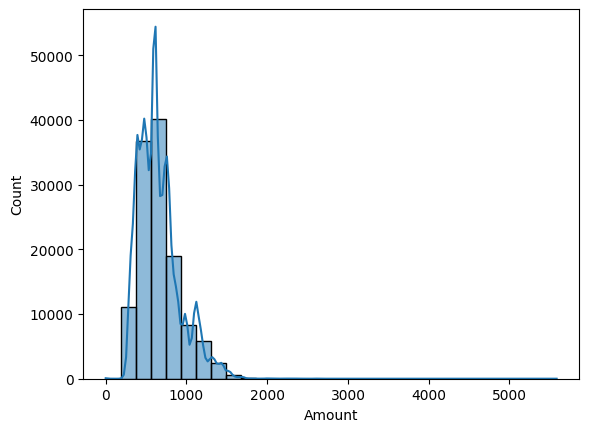

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="Amount", bins=30, kde=True)
plt.show()


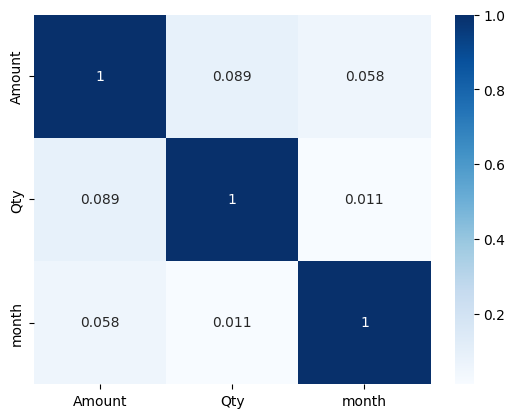

In [11]:
sns.heatmap(df[["Amount", "Qty", "month"]].corr(), annot=True, cmap="Blues")
plt.show()


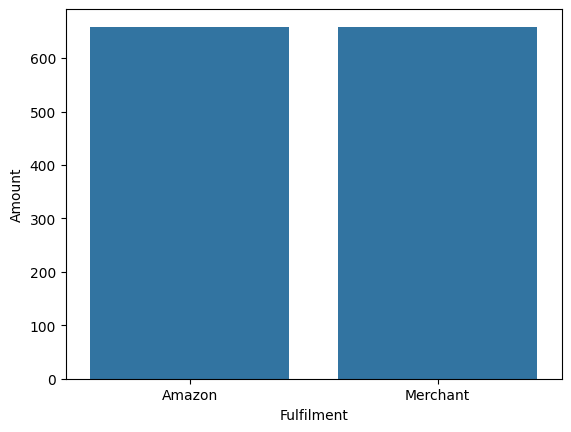

In [12]:
avg_amount_by_size = df.groupby("Fulfilment", as_index=False)["Amount"].mean()
sns.barplot(data=avg_amount_by_size, x="Fulfilment", y="Amount")
plt.show()


In [13]:
df.drop('day', axis=1, inplace=True)

In [14]:
df.drop('Date',axis=1 , inplace=True)

In [15]:
df.drop('Amount_missing',axis=1,inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124460 entries, 0 to 124459
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Status              124460 non-null  object 
 1   Fulfilment          124460 non-null  object 
 2   Sales Channel       124460 non-null  object 
 3   ship-service-level  124460 non-null  object 
 4   Category            124460 non-null  object 
 5   Size                124460 non-null  object 
 6   Courier Status      124460 non-null  object 
 7   Qty                 124460 non-null  int64  
 8   Amount              124460 non-null  float64
 9   ship-state          124460 non-null  object 
 10  B2B                 124460 non-null  bool   
 11  year                124460 non-null  int64  
 12  month               124460 non-null  int64  
dtypes: bool(1), float64(1), int64(3), object(8)
memory usage: 11.5+ MB


In [17]:
from sklearn.preprocessing import StandardScaler , PolynomialFeatures , OneHotEncoder
from sklearn.impute import KNNImputer , SimpleImputer



from sklearn.metrics import accuracy_score , f1_score , recall_score , precision_score , confusion_matrix , ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate , cross_val_predict, GridSearchCV ,KFold, StratifiedKFold
from sklearn.feature_selection import SelectFromModel

from imblearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel

In [18]:
cat_cols = [
    'Status',
    'Fulfilment',
    'Sales Channel ',
    'ship-service-level',
    'Category',
    'Size',
    'Courier Status',
    'ship-state'
]

In [19]:
X = df.drop('Amount', axis=1)
y = df['Amount']

In [20]:
y = np.log1p(df['Amount'])

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            cat_cols
        )
    ],
    remainder='passthrough'
)

In [51]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [52]:
X_encoded = preprocessor.fit_transform(X)

In [53]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['cat__Status_Cancelled' 'cat__Status_Pending'
 'cat__Status_Pending - Waiting for Pick Up' 'cat__Status_Shipped'
 'cat__Status_Shipped - Damaged'
 'cat__Status_Shipped - Delivered to Buyer'
 'cat__Status_Shipped - Lost in Transit'
 'cat__Status_Shipped - Out for Delivery'
 'cat__Status_Shipped - Picked Up'
 'cat__Status_Shipped - Rejected by Buyer'
 'cat__Status_Shipped - Returned to Seller'
 'cat__Status_Shipped - Returning to Seller' 'cat__Status_Shipping'
 'cat__Fulfilment_Amazon' 'cat__Fulfilment_Merchant'
 'cat__Sales Channel _Amazon.in' 'cat__Sales Channel _Non-Amazon'
 'cat__ship-service-level_Expedited' 'cat__ship-service-level_Standard'
 'cat__Category_Blouse' 'cat__Category_Bottom' 'cat__Category_Dupatta'
 'cat__Category_Ethnic Dress' 'cat__Category_Saree' 'cat__Category_Set'
 'cat__Category_Top' 'cat__Category_Western Dress' 'cat__Category_kurta'
 'cat__Size_3XL' 'cat__Size_4XL' 'cat__Size_5XL' 'cat__Size_6XL'
 'cat__Size_Free' 'cat__Size_L' 'cat__Size_M' 'cat__Size_S' 'cat

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [55]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',CatBoostRegressor())
])

In [56]:
pipeline.fit(X, y)

Learning rate set to 0.0847
0:	learn: 0.3694635	total: 7.77ms	remaining: 7.76s
1:	learn: 0.3562363	total: 10.6ms	remaining: 5.3s
2:	learn: 0.3446516	total: 13.6ms	remaining: 4.51s
3:	learn: 0.3346324	total: 16.4ms	remaining: 4.08s
4:	learn: 0.3260360	total: 19.3ms	remaining: 3.83s
5:	learn: 0.3185022	total: 22.4ms	remaining: 3.71s
6:	learn: 0.3119563	total: 25.9ms	remaining: 3.67s
7:	learn: 0.3064022	total: 28.8ms	remaining: 3.57s
8:	learn: 0.3015000	total: 31.3ms	remaining: 3.45s
9:	learn: 0.2973494	total: 34.6ms	remaining: 3.43s
10:	learn: 0.2935042	total: 37.3ms	remaining: 3.35s
11:	learn: 0.2902510	total: 40ms	remaining: 3.29s
12:	learn: 0.2875270	total: 42.7ms	remaining: 3.25s
13:	learn: 0.2852071	total: 45.1ms	remaining: 3.18s
14:	learn: 0.2831879	total: 47.6ms	remaining: 3.13s
15:	learn: 0.2814614	total: 50.1ms	remaining: 3.08s
16:	learn: 0.2799227	total: 53.4ms	remaining: 3.09s
17:	learn: 0.2786950	total: 56.7ms	remaining: 3.1s
18:	learn: 0.2775187	total: 59.5ms	remaining: 3.07

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Status', 'Fulfilment',
                                                   'Sales Channel ',
                                                   'ship-service-level',
                                                   'Category', 'Size',
                                                   'Courier Status',
                                                   'ship-state'])])),
                ('model', CatBoostRegressor(loss_function='RMSE'))])

In [57]:
pred = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)

In [58]:
y_test = y
y_test_actual = np.expm1(y_test)

pred_actual = np.expm1(pred)

In [59]:
cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    'MAE': -cv_results['test_mae'],
    'RMSE': -cv_results['test_rmse'],
    'R2': cv_results['test_r2']
})

cv_summary

In [61]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test_actual, pred_actual)

mse = mean_squared_error(y_test_actual, pred_actual)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_actual, pred_actual)

print("OOF MAE:", mae)
print("OOF RMSE:", rmse)
print("OOF R2:", r2)
print("Mean CV MAE:", cv_summary['MAE'].mean())
print("Mean CV RMSE:", cv_summary['RMSE'].mean())
print("Mean CV R2:", cv_summary['R2'].mean())

MAE: 131.01600745030598
RMSE: 185.06315094966462
R2: 0.48458033983502613


In [32]:
print(y_test.dtype)
print(pred[:10])


float64
[6.3697944 6.254761  6.134558  6.7031126 6.1205015 6.148238  6.6791162
 6.593636  6.1217856 6.7402987]


In [33]:
pred_actual = np.expm1(pred)

print(pred_actual[:10])

[582.93774 519.4851  460.53516 813.9385  454.09286 466.8923  794.61566
 729.43195 454.67764 844.81335]


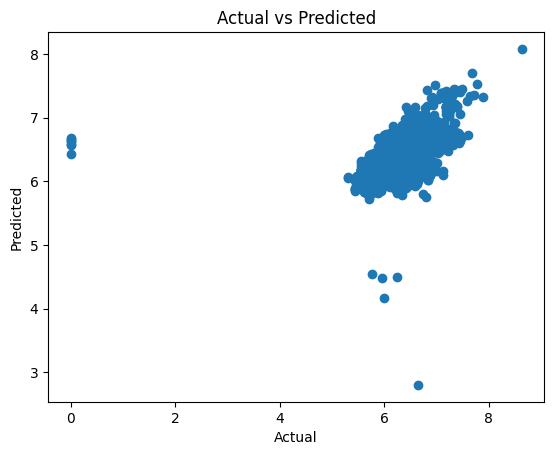

In [34]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [36]:
# Get feature names after preprocessing
feature_names = (
    pipeline.named_steps['preprocessor']
    .get_feature_names_out()
)

# Get feature importances from XGBoost
importances = (
    pipeline.named_steps['model']
    .feature_importances_
)

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort descending
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(20))

                                       Feature  Importance
27                         cat__Category_kurta    0.485739
25                           cat__Category_Top    0.158109
31                               cat__Size_6XL    0.040497
20                        cat__Category_Bottom    0.035248
30                               cat__Size_5XL    0.032803
19                        cat__Category_Blouse    0.032045
39               cat__Courier Status_Cancelled    0.022946
29                               cat__Size_4XL    0.021615
109                             remainder__Qty    0.017673
102                cat__ship-state_WEST BENGAL    0.011012
66                      cat__ship-state_KERALA    0.010013
58                         cat__ship-state_GOA    0.008663
80                      cat__ship-state_ODISHA    0.008512
17           cat__ship-service-level_Expedited    0.006941
13                      cat__Fulfilment_Amazon    0.006630
1                          cat__Status_Pending    0.0061